In [9]:
"""
test_downsampling.py
--------------------
Compares nearest neighbour and area averaging downsampling of SIC to AMSR2 resolution.
Plots the original SIC, nearest neighbour downsampled, and area averaged side by side.

Run from the project root:
    python test_downsampling.py
"""

import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import rioxarray
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

TRAINING_INDEX_CSV = "/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/training_index.csv"
DATA_DIRS = [
    '/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2',
    '/dmidata/projects/asip-cms/reproc',
]
SCALE_FACTOR = 25
SAMPLE_IDX   = 0   # change to inspect a different swath


def load_sic(sic_path):
    """Load native 80m SIC, return (sic, invalid_mask) as numpy arrays."""
    with rioxarray.open_rasterio(sic_path) as da:
        raw = da.values.astype(np.float32)
    sic     = raw[0]
    invalid = (sic == 254) | (sic == 255)
    sic_clean = sic.copy()
    sic_clean[invalid] = np.nan
    return sic_clean, invalid


def nearest_neighbour(sic, invalid, scale=SCALE_FACTOR):
    """Downsample by picking the centre pixel of each scale×scale block."""
    h, w   = sic.shape
    h_lr   = h // scale
    w_lr   = w // scale
    offset = scale // 2   # centre of each block

    sic_lr  = np.full((h_lr, w_lr), np.nan, dtype=np.float32)
    mask_lr = np.ones((h_lr, w_lr), dtype=bool)

    for i in range(h_lr):
        for j in range(w_lr):
            src_i = i * scale + offset
            src_j = j * scale + offset
            if not invalid[src_i, src_j]:
                sic_lr[i, j]  = sic[src_i, src_j]
                mask_lr[i, j] = False

    return sic_lr, mask_lr

def bicubic(sic, invalid, amsr2_h, amsr2_w):
    """
    Downsample SIC to AMSR2 resolution using bicubic interpolation.
    Standard method in AMSR2 sea ice SR literature:
      - Liu et al. (2023, Remote Sensing, doi:10.3390/rs15225401)
      - MFM-Net (Gao et al., arXiv:2406.01240, 2024)
    Invalid pixels are set to nan before interpolating to avoid contaminating
    valid pixels near boundaries. Mask is re-derived from nan in output.
    Bicubic overshoot at sharp boundaries is clipped to [0, 100].
    """
    sic_filled = sic.copy()
    sic_filled[invalid] = np.nan

    sic_t    = torch.from_numpy(sic_filled)[None, None]
    sic_lr_t = F.interpolate(
        sic_t,
        size=(amsr2_h, amsr2_w),
        mode='bicubic',
        align_corners=False,
    )
    sic_lr  = sic_lr_t.numpy()[0, 0]
    mask_lr = np.isnan(sic_lr) | (sic_lr < 0.0) | (sic_lr > 100.0)
    sic_lr  = np.clip(sic_lr, 0.0, 100.0)
    return sic_lr, mask_lr

def area_average(sic, invalid, scale=SCALE_FACTOR):
    """Downsample by averaging valid pixels in each scale×scale block."""
    valid_float = (~invalid).astype(np.float32)
    sic_filled  = np.where(invalid, 0.0, sic)

    sic_t   = torch.from_numpy(sic_filled)[None, None]
    valid_t = torch.from_numpy(valid_float)[None, None]

    k = scale
    sic_sum   = F.avg_pool2d(sic_t * valid_t, kernel_size=k, stride=k) * k**2
    valid_sum = F.avg_pool2d(valid_t,          kernel_size=k, stride=k) * k**2
    valid_sum = valid_sum.clamp(min=1.0)

    sic_lr   = (sic_sum / valid_sum).numpy()[0, 0]
    valid_lr = F.avg_pool2d(valid_t, kernel_size=k, stride=k).numpy()[0, 0]
    mask_lr  = valid_lr < 0.5

    sic_lr[mask_lr] = np.nan
    return sic_lr, mask_lr


def plot_comparison(sic_native, sic_nn, sic_avg, sic_bic, mask_nn, mask_avg, mask_bic, save_path=None):
    """Plot original SIC, nearest neighbour, area average and bicubic interpolation side by side."""

    # Use a custom colormap: white for NaN, Blues_r for valid SIC
    cmap = plt.cm.Blues_r.copy()
    cmap.set_bad(color='lightgray')   # NaN → gray (land / invalid)

    fig, axes = plt.subplots(1, 4, figsize=(18, 6))
    vmin, vmax = 0, 100

    # ── Original native SIC (80m) ─────────────────────────────────────────────
    im0 = axes[0].imshow(sic_native, cmap=cmap, vmin=vmin, vmax=vmax,
                          interpolation='nearest')
    axes[0].set_title(f'Original SIC (80m)\n{sic_native.shape[0]}×{sic_native.shape[1]} px', fontsize=11)
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, label='SIC (%)')

    # ── Nearest neighbour ─────────────────────────────────────────────────────
    im1 = axes[1].imshow(sic_nn, cmap=cmap, vmin=vmin, vmax=vmax,
                          interpolation='nearest')
    axes[1].set_title(f'Nearest neighbour (÷{SCALE_FACTOR})\n{sic_nn.shape[0]}×{sic_nn.shape[1]} px', fontsize=11)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='SIC (%)')

    # ── Area average ──────────────────────────────────────────────────────────
    im2 = axes[2].imshow(sic_avg, cmap=cmap, vmin=vmin, vmax=vmax,
                          interpolation='nearest')
    axes[2].set_title(f'Area average (÷{SCALE_FACTOR})\n{sic_avg.shape[0]}×{sic_avg.shape[1]} px', fontsize=11)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='SIC (%)')

    # ── Bicubic interpolation ────────────────────────────────────────────────
    im3 = axes[3].imshow(sic_bic, cmap=cmap, vmin=vmin, vmax=vmax,
                          interpolation='nearest')
    axes[3].set_title(f'Bicubic interpolation (÷{SCALE_FACTOR})\n{sic_bic.shape[0]}×{sic_bic.shape[1]} px', fontsize=11)
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046, label='SIC (%)')

    plt.suptitle(f'SIC downsampling comparison — sample {SAMPLE_IDX}', fontsize=13)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


def plot_difference(sic_nn, sic_avg, save_path=None):
    """Plot pixel-wise difference between the two methods."""
    diff = sic_avg - sic_nn

    cmap = plt.cm.bwr.copy()
    cmap.set_bad(color='lightgray')

    abs_max = np.nanmax(np.abs(diff))
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(diff, cmap=cmap, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
    ax.set_title('Area average − Nearest neighbour\n(positive = area avg higher)', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label='Δ SIC (%)')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()

def upsample_to_native(sic_lr, native_h, native_w):
    """Upsample a downsampled SIC back to native resolution using bilinear.

    Upsamples both the SIC values and a weight mask simultaneously.
    Any upsampled pixel that drew more than 10% of its weight from a NaN
    source pixel is masked out — this prevents 0% SIC bleed along coastlines
    where bilinear interpolation would otherwise average NaN (treated as 0)
    with valid ocean/ice pixels.
    """
    nan_mask = np.isnan(sic_lr)

    # Fill NaN temporarily so interpolation has something to work with
    sic_filled = np.where(nan_mask, 0.0, sic_lr)

    sic_t  = torch.from_numpy(sic_filled.astype(np.float32))[None, None]
    # Valid mask: 1 where valid, 0 where NaN
    valid_t = torch.from_numpy((~nan_mask).astype(np.float32))[None, None]

    # Upsample both values and validity weights with bilinear
    sic_up   = F.interpolate(sic_t,   size=(native_h, native_w), mode='bilinear', align_corners=False)
    valid_up = F.interpolate(valid_t, size=(native_h, native_w), mode='bilinear', align_corners=False)

    sic_up   = sic_up.numpy()[0, 0]
    valid_up = valid_up.numpy()[0, 0]

    # Mask any pixel that drew >10% of its weight from a NaN source pixel
    sic_up[valid_up < 0.9] = np.nan

    return sic_up
 
 
def plot_vs_native(sic_native, sic_nn, sic_avg, sic_bic, save_path=None):
    """
    Upsample bicubic and area average back to native resolution and compare
    against the original. Shows where each method loses information.
    Row 1: original | bicubic upsampled | area avg upsampled
    Row 2: -        | diff bicubic      | diff area avg
    """
    native_h, native_w = sic_native.shape
    sic_nn_up  = upsample_to_native(sic_nn, native_h, native_w)
    sic_avg_up = upsample_to_native(sic_avg, native_h, native_w)
    sic_bic_up = upsample_to_native(sic_bic, native_h, native_w)

    diff_nn  = sic_nn_up - sic_native
    diff_avg = sic_avg_up - sic_native
    diff_bic = sic_bic_up - sic_native
    abs_max  = np.nanmax(np.abs(np.stack([diff_nn, diff_avg, diff_bic])))
 
    cmap_sic  = plt.cm.Blues_r.copy();  cmap_sic.set_bad(color='lightgray')
    cmap_diff = plt.cm.bwr.copy();   cmap_diff.set_bad(color='lightgray')
 
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    vmin, vmax = 0, 100
 
    # Row 1 — images
    im00 = axes[0, 0].imshow(sic_native,  cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[0, 0].set_title('Original (80m)', fontsize=11)
    axes[0, 0].axis('off')
    plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, label='SIC (%)')
 
    im01 = axes[0, 1].imshow(sic_nn_up,  cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[0, 1].set_title('Nearest neighbour ↓ then bilinear ↑', fontsize=11)
    axes[0, 1].axis('off')
    plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, label='SIC (%)')
 
    im02 = axes[0, 2].imshow(sic_avg_up,  cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[0, 2].set_title('Area avg ↓ then bilinear ↑', fontsize=11)
    axes[0, 2].axis('off')
    plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, label='SIC (%)')

    im03 = axes[0, 3].imshow(sic_bic_up,  cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[0, 3].set_title('Bicubic ↓ then bilinear ↑', fontsize=11)
    axes[0, 3].axis('off')
    plt.colorbar(im03, ax=axes[0, 3], fraction=0.046, label='SIC (%)')
 
    # Row 2 — differences vs native
    axes[1, 0].axis('off')   # empty
 
    im11 = axes[1, 1].imshow(diff_nn, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
    axes[1, 1].set_title('Nearest neighbour − Original', fontsize=11)
    axes[1, 1].axis('off')
    plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, label='Δ SIC (%)')
 
    im12 = axes[1, 2].imshow(diff_avg, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
    axes[1, 2].set_title('Area avg − Original', fontsize=11)
    axes[1, 2].axis('off')
    plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, label='Δ SIC (%)')

    im13 = axes[1, 3].imshow(diff_bic, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
    axes[1, 3].set_title('Bicubic − Original', fontsize=11)
    axes[1, 3].axis('off')
    plt.colorbar(im13, ax=axes[1, 3], fraction=0.046, label='Δ SIC (%)')
 
    # Print stats
    print(f'\nVs native (RMSE):')
    print(f'  Nearest neighbour : {np.sqrt(np.nanmean(diff_nn**2)):.2f}%')
    print(f'  Area average : {np.sqrt(np.nanmean(diff_avg**2)):.2f}%')
    print(f'  Bicubic      : {np.sqrt(np.nanmean(diff_bic**2)):.2f}%')

    plt.suptitle(f'Downsampled then upsampled vs original — sample {SAMPLE_IDX}', fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()

SIC file: /dmidata/projects/asip-cms/reproc/2024/01/17/S1A_EW_GRDM_1SDH_20240117T083035_20240117T083135_052144_064D8A_AFD5_SIC.tiff
Loading native SIC...
  Native shape : (4995, 5244)
Nearest neighbour downsampling...
  Output shape : (199, 209)
Bicubic downsampling...
  Output shape : (199, 209)
Area averaging downsampling...
  Output shape : (199, 209)

Nearest neighbour — valid pixels: 35731  
mean SIC: 58.3%
Max absolute difference: 30.64%
Mean absolute difference: 0.22%
Bicubic interpolation — valid pixels: 34640  
mean SIC: 58.0%
Max absolute difference: 61.70%
Mean absolute difference: 0.76%
Area average      — valid pixels: 35726  
mean SIC: 58.3%
Max absolute difference: 0.00%
Mean absolute difference: 0.00%


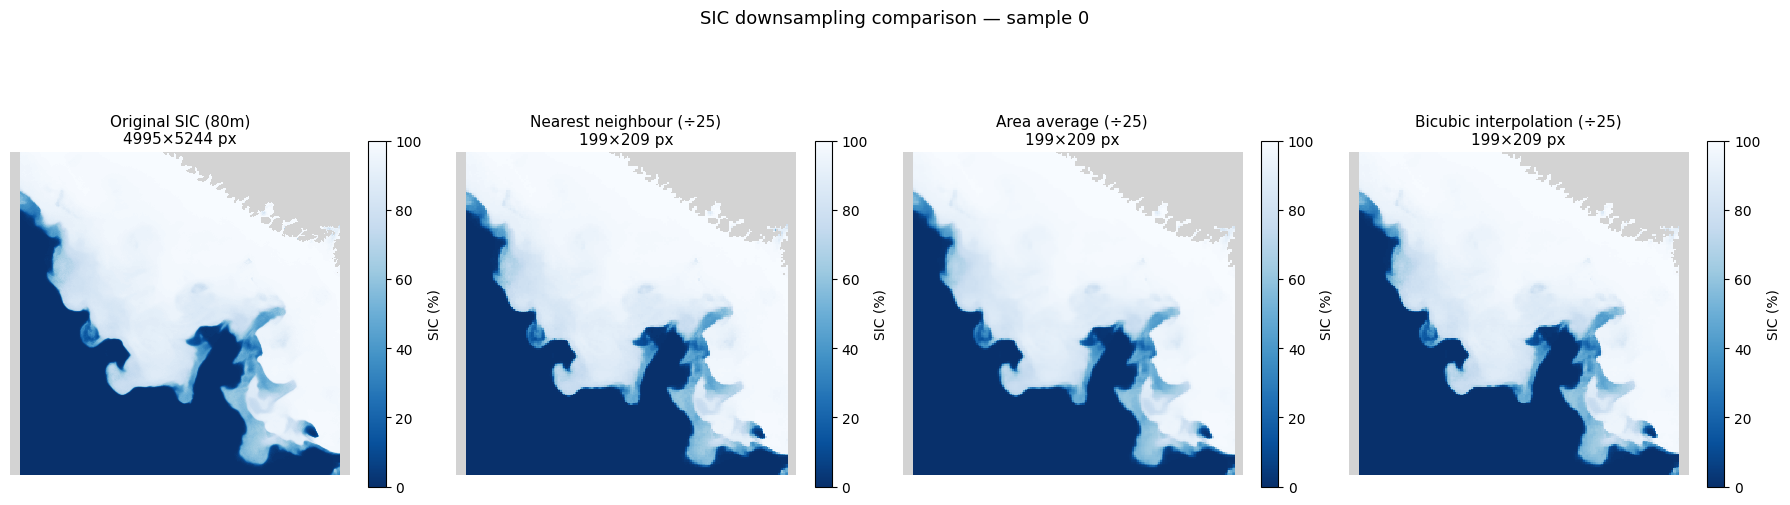


Vs native (RMSE):
  Nearest neighbour : 3.06%
  Area average : 3.01%
  Bicubic      : 1.07%


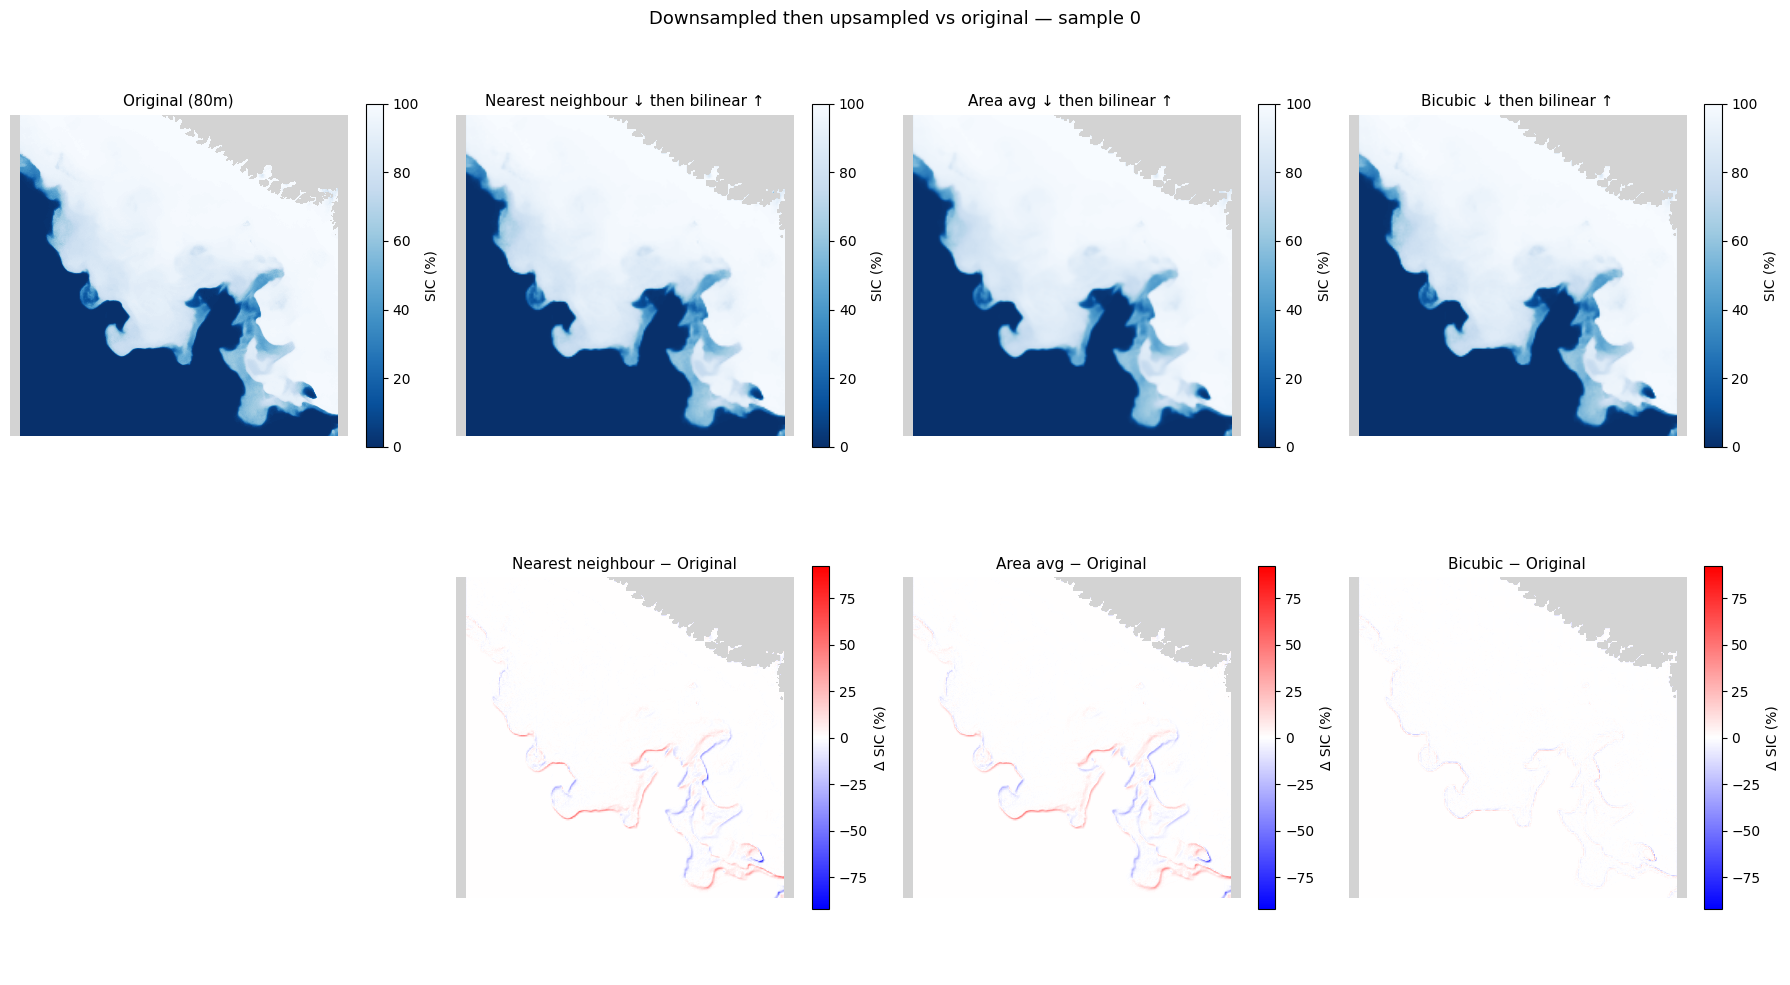

In [10]:

if __name__ == '__main__':
    # ── Load file paths from CSV ──────────────────────────────────────────────
    df  = pd.read_csv(TRAINING_INDEX_CSV)
    row = df.iloc[SAMPLE_IDX]

    timestamp = row['timestamp']
    y, m, d   = timestamp[:4], timestamp[5:7], timestamp[8:10]
    sic_path  = os.path.join(DATA_DIRS[1], y, m, d, row['sic_file'])
    print(f'SIC file: {sic_path}')

    # ── Load and downsample ───────────────────────────────────────────────────
    print('Loading native SIC...')
    sic_native, invalid = load_sic(sic_path)
    print(f'  Native shape : {sic_native.shape}')

    print('Nearest neighbour downsampling...')
    sic_nn,  mask_nn  = nearest_neighbour(sic_native, invalid)
    print(f'  Output shape : {sic_nn.shape}')

    print('Bicubic downsampling...')
    sic_bic, mask_bic = bicubic(sic_native, invalid, amsr2_h=sic_native.shape[0]//SCALE_FACTOR, amsr2_w=sic_native.shape[1]//SCALE_FACTOR)
    print(f'  Output shape : {sic_bic.shape}')

    print('Area averaging downsampling...')
    sic_avg, mask_avg = area_average(sic_native, invalid)
    print(f'  Output shape : {sic_avg.shape}')

    # ── Summary stats ─────────────────────────────────────────────────────────
    print(f'\nNearest neighbour — valid pixels: {(~mask_nn).sum()}  '
          f'\nmean SIC: {np.nanmean(sic_nn):.1f}%'
          f'\nMax absolute difference: {np.nanmax(np.abs(sic_avg - sic_nn)):.2f}%'
          f'\nMean absolute difference: {np.nanmean(np.abs(sic_avg - sic_nn)):.2f}%')
    print(f'Bicubic interpolation — valid pixels: {(~mask_bic).sum()}  '
          f'\nmean SIC: {np.nanmean(sic_bic):.1f}%'
          f'\nMax absolute difference: {np.nanmax(np.abs(sic_avg - sic_bic)):.2f}%'
          f'\nMean absolute difference: {np.nanmean(np.abs(sic_avg - sic_bic)):.2f}%')
    print(f'Area average      — valid pixels: {(~mask_avg).sum()}  '
          f'\nmean SIC: {np.nanmean(sic_avg):.1f}%'
          f'\nMax absolute difference: {np.nanmax(np.abs(sic_avg - sic_avg)):.2f}%'
          f'\nMean absolute difference: {np.nanmean(np.abs(sic_avg - sic_avg)):.2f}%')

    # ── Plot ──────────────────────────────────────────────────────────────────
    plot_comparison(
        sic_native, sic_nn, sic_avg, sic_bic, mask_nn, mask_avg, mask_bic)
#     plot_difference(
#         sic_nn, sic_avg)
    plot_vs_native(
        sic_native, sic_nn, sic_avg, sic_bic,
    )